# Lecture 2 (12 Sep 2026)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kosavina/hse-python-2026/blob/main/Lecture_2.ipynb)

**Block 1 — the machine**

1. Objects, and the dot
2. Names, namespaces, mutability
3. Functions: `return` vs `print`
4. Assignment and the fundamental types
5. Casting — and three different ways to make a whole number
6. Operators, and `is` vs `==`
7. **Trap 1 — who owns the list?**

**Block 2 — the containers**

8. Arguments, defaults, scope
9. `lambda`, `*args`, `**kwargs`
10. Strings and slicing
11. f-strings
12. Lists, tuples, dictionaries, sets


---
---
# Block 1 — the machine

---
## 1 · Objects, and the dot

Everything in Python is an object. An object holds **data** (attributes) and **things it can do** (methods). The dot `.` is how you reach both. `type()` tells you what you are holding.

That is the whole of object-orientation that you need today. We are not going to write classes.

### Intuitive Explanation


Car

*   The initial mileage is zero (mileage)
*   Maintenance every 10000 miles (dist_to_maintenance)
*   The color is chosen by the buyer (color)
*   It can move (move)



In [ ]:
class PyCar:
    def __init__(self, color):
        self.mileage = 0
        self.dist_to_maintenance = 10000
        self.color = color

    def move(self, distance):
        self.mileage = self.mileage + distance
        self.dist_to_maintenance = self.dist_to_maintenance - distance

    def paint(self, new_color):
        self.color = new_color

In [ ]:
my_car = PyCar('red')

In [ ]:
print(my_car.color)

In [ ]:
my_car.move(10)

In [ ]:
my_car.mileage

In [ ]:
my_car.dist_to_maintenance


Paint shop
*   It can paint objects that have a color attribute

In [ ]:
def paint(obj, new_color):
    obj.color = new_color
    return obj

In [ ]:
my_car = paint(my_car, 'green')
print(my_car.color)

---
## 2 · Names, namespaces, mutability

**This is the most important section of Block 1.** A name is not a box that holds a value — it is a label stuck onto an object. Two labels can sit on the same object, and that is where Trap 2 comes from.

### Memory (Variables and Namespaces)

Variable names in Python can contain alphanumerical characters `a-z`, `A-Z`, `0-9` and some special characters such as `_`. Normal variable names must start with a letter.

By convention, variable names start with a lower-case letter, and Class names start with a capital letter.

In addition, there are a number of Python keywords that cannot be used as variable names. These keywords are:

1.	True
2.	False
3.	None
4.	and
5.	as
6.	assert
7.	async
8.	await
9.	break
10.	class
11.	continue
12.	def
13.	del
14.	elif
15.	else
16.	except
17.	finally
18.	for
19.	from
20.	global
21.	if
22.	import
23.	in
24.	is
25.	lambda
26.	nonlocal
27.	not
28.	or
29.	pass
30.	raise
31.	return
32.	try
33.	while
34.	with
35.	yield

Note: Be aware of the keyword `lambda`, which could easily be a natural variable name in a scientific program. But being a keyword, it cannot be used as a variable name.

[Built-in Functions](https://docs.python.org/3/library/functions.html)

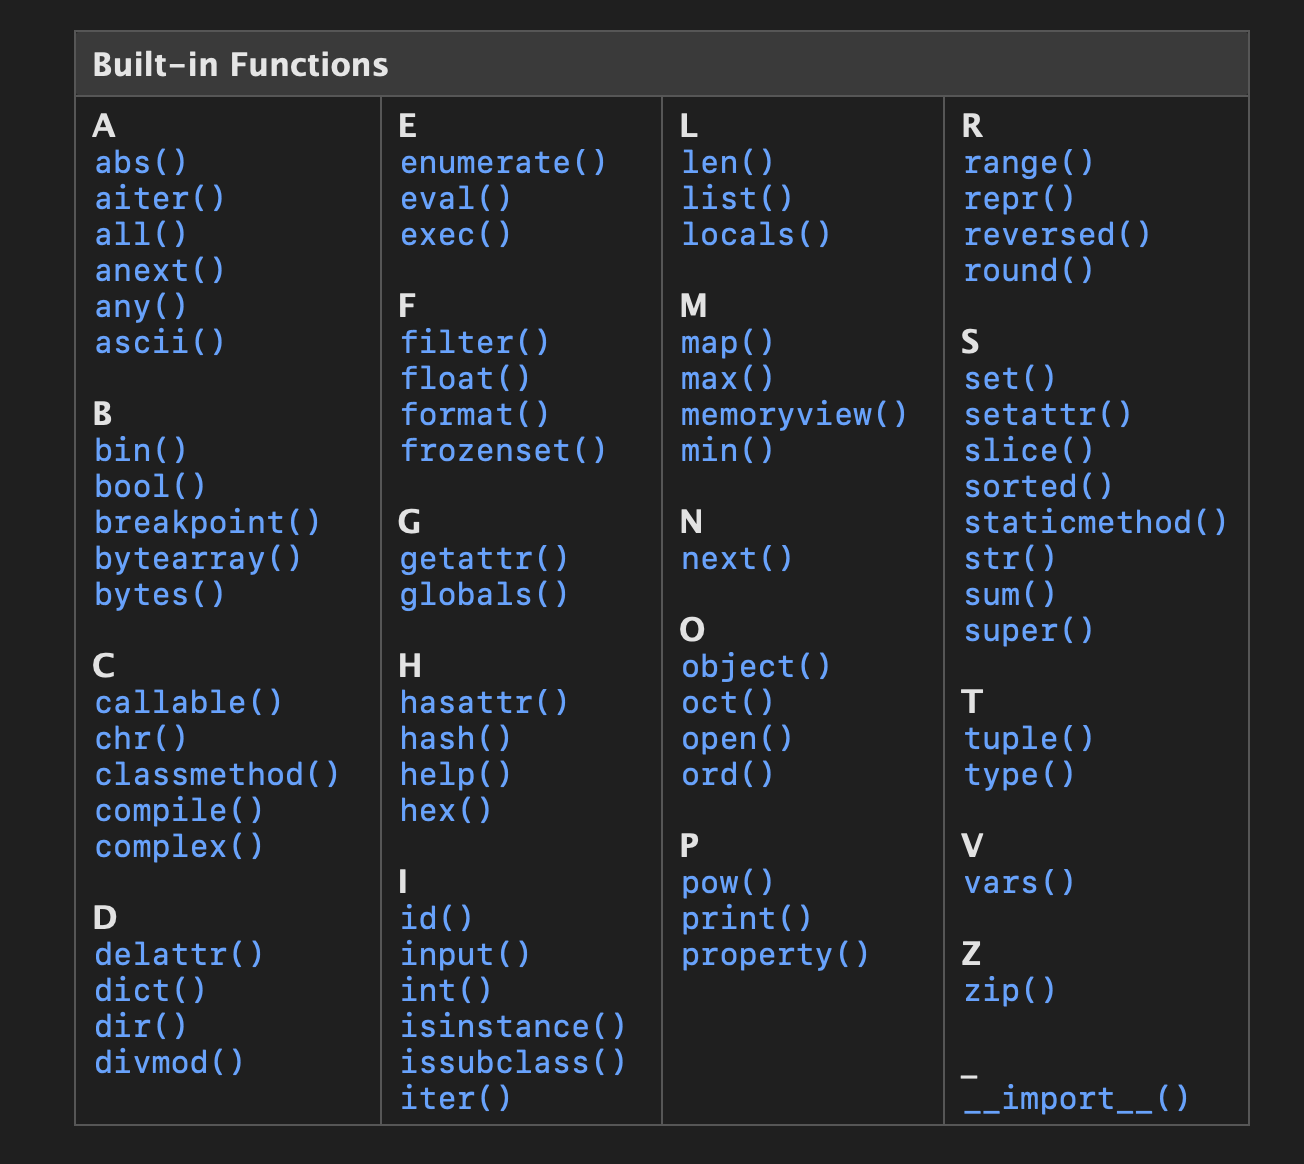

Names resolution order:

1.  Local Namespace
2.  Enclosing Namespace
3.  Global Namespace
4.  Built-in Namespace

In [ ]:
currency = "RUB"                    # >>> GLOBAL  (module / notebook level)

def portfolio():
    broker = "BCS"                  # >>> ENCLOSING (local to portfolio, visible to position)

    def position():
        ticker = "SBER"             # >>> LOCAL (local to position)

        print(ticker)               # L -- found here, search stops immediately
        print(broker)               # E -- not local; found in portfolio()
        print(currency)             # G -- not local, not enclosing; found at module level
        print(len("SBER"))          # B -- 'len' found nowhere above; it is a built-in

    position()

portfolio()

In [ ]:
fee = "G: global fee"

def outer():
    fee = "E: enclosing fee"

    def inner():
        fee = "L: local fee"
        print("  inner sees ->", fee)      # L wins, search stops
    inner()
    print("  outer sees ->", fee)          # outer's own local -- inner never touched it

outer()
print("  module sees ->", fee)             # untouched by either function


def outer2():                              # no local in inner
    fee = "E: enclosing fee"
    def inner():
        print("  no local  ->", fee)       # E -- falls through one level
    inner()
outer2()


def outer3():                              # no local, no enclosing
    def inner():
        print("  no L, no E ->", fee)      # G
    inner()
outer3()

In [ ]:
fee = "G: original"

def outer():
    fee = "E: original"

    def plain():
        fee = "written by plain()"        # creates a NEW local. Changes nothing outside.

    def with_nonlocal():
        nonlocal fee                      # bind to the nearest ENCLOSING fee -> outer's
        fee = "written by with_nonlocal()"

    def with_global():
        global fee                        # bind to the MODULE fee -> skips outer entirely
        fee = "written by with_global()"

    print("start          | outer:", fee, "| module:", globals()["fee"])
    plain()
    print("after plain    | outer:", fee, "| module:", globals()["fee"])
    with_nonlocal()
    print("after nonlocal | outer:", fee, "| module:", globals()["fee"])
    with_global()
    print("after global   | outer:", fee, "| module:", globals()["fee"])

outer()

## Mutability

Immutable types cannot be changed after their creation. Any operation that modifies an immutable object creates a new object in memory. Common examples include:
* Integers
* Floats
* String
* Tuples
* Frozensets
* Bytes

Mutable types can be changed or modified after their creation. When a mutable object is altered, its original value is updated in memory. Common examples include:
* Lists
* Dictionaries
* Sets
* Bytearrays

| Type | Define | Access | Properties |
|---|---|---|---|
| `list` | `[1, 2]` or `list(...)` | `xs[i]` by position | ordered, mutable, duplicates allowed |
| `tuple` | `(1, 2)` or `tuple(...)` | `t[i]` by position | ordered, **immutable**, duplicates allowed |
| `str` | `"abc"` or `'abc'` | `s[i]` by position | ordered, **immutable**, text (Unicode) |
| `dict` | `{"a": 1}` or `dict(...)` | `d[key]` by key | ordered (3.7+), mutable, unique keys |
| `set` | `{1, 2}` or `set(...)` | no `[]` index | **unordered**, mutable, unique items |

In [ ]:
# Mutable = can be changed in place. Immutable = cannot.

prices = [100, 200, 300]      # list  -> MUTABLE
prices[0] = 999               # works
print("list  :", prices)

ticker = "SBER"               # str   -> IMMUTABLE
try:
    ticker[0] = "X"           # same syntax, different answer
except TypeError as e:
    print("str   :", e)

point = (10, 20)              # tuple -> IMMUTABLE
try:
    point[0] = 99
except TypeError as e:
    print("tuple :", e)

In [ ]:
# MUTABLE: same object before and after
prices = [100, 200]
before = id(prices)
prices.append(300)
print("list  same object?", id(prices) == before, prices)

# IMMUTABLE: a NEW object is built, the name is re-pointed
n = 5
before = id(n)
n = n + 1
print("int   same object?", id(n) == before, n)

s = "SBER"
before = id(s)
s = s + "P"
print("str   same object?", id(s) == before, s)

In [ ]:
# MUTABLE -- the change is visible through both names
a = [1, 2, 3]
b = a
b.append(4)
print("mutable  a:", a, " b:", b)

# IMMUTABLE -- impossible to have this problem
x = 5
y = x
y = y + 1
print("immutable x:", x, " y:", y)

In [ ]:
# An immutable box with a mutable thing inside it
row = ("SBER", [100, 200])

# The tuple refuses to swap its contents...
try:
    row[1] = [999]
except TypeError as e:
    print("rebind slot :", e)

# ...but the list inside is still a list.
row[1].append(300)
print("row now     :", row)

# Consequence: it cannot be a dict key or go in a set
try:
    {row: "value"}
except TypeError as e:
    print("as dict key :", e)

Summary:

	•	Mutable types: Can be changed after creation (e.g., list, dict, set, bytearray).
	•	Immutable types: Cannot be changed after creation (e.g., int, float, str, tuple, frozenset, bytes).

In general, immutable objects are hashable and can be used as keys in dictionaries or elements in sets, while mutable objects are not.

---
## 3 · Functions: `return` vs `print`


`print` shows a value to a human. `return` hands a value back to the program. They are not the same thing, and a function that only prints gives you back `None`.

In [ ]:
# A function gives back the value after return. That value can be stored:

def add(a, b):
    return a + b

x = add(2, 3)   # x is 5

In [ ]:
# print only shows something on the screen. It does not give a useful value back (it returns None):

def show(a, b):
    print(a + b)

x = show(2, 3)  # prints 5, but x is None

## Functions

### Definition

* Mathematical Function:

  A mathematical function is a relation between a set of inputs (domain) and a set of possible outputs (codomain), such that each input is related to exactly one output. A mathematical function is typically written as  f(x) , where  x  is the input (argument) and  f(x)  is the output.

* Python Function:

  In Python, a function is a block of reusable code that performs a specific task. It takes arguments (inputs), processes them, and returns a result (output). In Python, functions are defined using the def keyword and can be invoked with specific arguments.

### Inputs

* Mathematical Function:

  The input values (independent variable) come from a defined domain. For example, for the function  f(x) = x^2 , the input can be any real number, and the function returns its square.

* Python Function:

  Python functions can take multiple types of inputs, including integers, strings, lists, and other objects. For example, in Python, you can define a function like this:

In [ ]:
def square(x):
    return x ** 2

In [ ]:
def print_square(x):
    print(x ** 2)


In [ ]:
x = square(10)

In [ ]:
x

In [ ]:
type(x)

In [ ]:
x = print_square(10)

In [ ]:
type(x)

### Outputs

* Mathematical Function:

  A mathematical function produces one output for each input. The output depends on the function’s rule. For example, for the function  f(x) = x^2, when  x = 2, the output is  f(2) = 4

* Python Function:

  A Python function also returns a result based on its inputs. However, it can return multiple values (in the form of a tuple), and the output can be of any data type (int, float, string, list, etc.). It **never** returns nothing (at least None-type object is returned)

In [ ]:
def multiply_and_return(a, b):
    return a * b

In [ ]:
def multiply_and_print(a, b):
    print(a * b)

In [ ]:
def multiply_print_and_return(a, b):
    print(a * b)
    return a * b

In [ ]:
x = multiply_and_return(5, 6)
print(x)

In [ ]:
x = multiply_and_print(5, 6)
print(x)

In [ ]:
x = multiply_print_and_return(5, 6)
print(x)

---
## 4 · Assignment and the fundamental types

### Assignment



The assignment operator in Python is `=`. Python is a dynamically typed language, so we do not need to specify the type of a variable when we create one.

Assigning a value to a new variable creates the variable:

In [ ]:
# variable assignments
x = 1.0
my_variable = 12.2

Although not explicitly specified, a variable does have a type associated with it. The type is derived from the value that was assigned to it.

In [ ]:
type(x)

If we assign a new value to a variable, its type can change.

In [ ]:
x = 1

In [ ]:
type(x)

If we try to use a variable that has not yet been defined we get an `NameError`:

In [ ]:
print(u)

### Fundamental types

In [ ]:
# integers
x = 1
type(x)

In [ ]:
# float
x = 1.
type(x)

In [ ]:
# boolean
b1 = True
b2 = False

type(b1)

---
## 5 · Casting

Three different ways to turn `2.5` into a whole number, and they disagree. Watch this one closely — it is a silent source of wrong totals.

### Type casting

In [ ]:
x = 1.5

print(x, type(x))

In [ ]:
print(x, type(x))

x = int(x)

print(x, type(x))

In [ ]:
x = 2.5
y = 3.5

In [ ]:
print(int(x), int(y))

In [ ]:
print(round(x), round(y))

In [ ]:
import math

In [ ]:
print(math.ceil(x), math.ceil(y))

In [ ]:
float(int(x))

**PREDICT.** You just saw `round(2.5)` and `round(3.5)`.

Write down what you expect from each of these *before* running the cell:

`round(0.5)`, `round(1.5)`, `round(2.5)`, `round(-0.5)`, `round(-1.5)`

In [ ]:
PREDICTION_ROUND = "..."

print(round(0.5), round(1.5), round(2.5), round(-0.5), round(-1.5))

This is **banker's rounding**: Python rounds a `.5` to the nearest **even** number, not always upward. It is in the IEEE 754 standard and it exists to stop a long column of numbers from drifting upward.

It also means that `round()` does not do what the arithmetic you were taught at school does. Over 254 rows, that difference is real money. If you want "always up at .5", you have to say so explicitly — `math.floor(x + 0.5)`.

---
## 6 · Operators, and `is` vs `==`

`/` is not `//`. `**` is not `^`. And `is` is not `==` — the last one is the one that will bite you.

### Operators and comparisons

Most operators and comparisons in Python work as one would expect:

* Arithmetic operators `+`, `-`, `*`, `/`, `//` (integer division), '**' power


In [ ]:
1 + 2, 1 - 2, 1 * 2, 1 / 2

In [ ]:
1.0 + 2.0, 1.0 - 2.0, 1.0 * 2.0, 1.0 / 2.0

In [ ]:
3 / 2

In [ ]:
3 // 2

In [ ]:
# Integer division of float numbers
3.0 // 2.0

In [ ]:
# Note! The power operators in python isn't ^, but **
2 ** 2

Note: The `/` operator always performs a floating point division in Python 3.x.
This is not true in Python 2.x, where the result of `/` is always an integer if the operands are integers.
to be more specific, `1/2 = 0.5` (`float`) in Python 3.x, and `1/2 = 0` (`int`) in Python 2.x (but `1.0/2 = 0.5` in Python 2.x).

* The boolean operators are spelled out as the words `and`, `not`, `or`.

In [ ]:
False and False

In [ ]:
True and False

In [ ]:
True or True

In [ ]:
False or False

In [ ]:
not False

* Comparison operators `>`, `<`, `>=` (greater or equal), `<=` (less or equal), `==` equality, `!=` non-equality, `is` identical.

In [ ]:
x = 1
y = 2

In [ ]:
x == y

In [ ]:
x != y

In [ ]:
2 > 1, 2 < 1

In [ ]:
2 > 2, 2 < 2

In [ ]:
2 >= 2, 2 <= 2

In [ ]:
x = 1
y = 2

In [ ]:
x = y

In [ ]:
x == y

In [ ]:
# equality
[1,2] == [1,2]

### `is` versus `==`, stated once

- `==` asks: **do these two have the same value?**
- `is` asks: **are these two the same object in memory?**

For numbers and strings you can get away with confusing them, because Python quietly reuses small objects. For lists you cannot. Keep this in your head for the next ten minutes.

In [ ]:
x = 55000
y = 55000

In [ ]:
x == y

In [ ]:
x is y

---
## 7 · Trap 1 — who owns the list?

Three implementations of one sentence. All three run. They do not do the same thing.

In [ ]:
def remove_negatives_v1(values):
    """Build a new list and return it."""
    result = []
    for x in values:
        if x >= 0:
            result.append(x)
    return result


def remove_negatives_v2(values):
    """Edit the list we were given, in place."""
    for x in values:
        if x < 0:
            values.remove(x)


def remove_negatives_v3(values):
    """Edit in place, but walk over a copy."""
    for x in values[:]: # values[:] is a *slice of the whole list* -- a copy
        if x < 0:
            values.remove(x)

**PREDICT — all three, before running anything.**

For each version, with the input `[3, -1, -2, 5]`:

1. What does the function **return**?
2. What does the caller's original list **look like afterwards**?

In [ ]:
PREDICTION_V1_RETURNS = "..."
PREDICTION_V1_LEAVES  = "..."
PREDICTION_V2_RETURNS = "..."
PREDICTION_V2_LEAVES  = "..."
PREDICTION_V3_RETURNS = "..."
PREDICTION_V3_LEAVES  = "..."

In [ ]:
data = [3, -1, -2, 5]
out  = remove_negatives_v1(data)
print("v1 returned:", out)
print("v1 left    :", data)

In [ ]:
data = [3, -1, -2, 5]
out  = remove_negatives_v2(data)
print("v2 returned:", out)
print("v2 left    :", data)

In [ ]:
data = [3, -1, -2, 5]
out  = remove_negatives_v3(data)
print("v3 returned:", out)
print("v3 left    :", data)

### What just happened

Two separate things went wrong in `v2`, and both are on today's syllabus.

**(a) No `return` means `None`.** A function that ends without a `return` statement still returns something: it returns `None`. `print` shows you a value; `return` hands it back. They are not the same and this is the distinction from the Functions section.

**(b) Never mutate a list while you are looping over it.** The `for` loop walks by position: 0, 1, 2, ... When `.remove()` deletes `-1` at position 1, every later element slides left by one — but the loop has already moved on to position 2. It steps straight over `-2`. The loop skips exactly the elements that follow a deletion.

`v3` fixes (b) by iterating over `values[:]`, a copy, while mutating the original. It still returns `None`.

### And the part that bites hardest

`v1` leaves your input alone. `v2` and `v3` **destroy it**. If you call `v2` and then use `data` later expecting the original numbers, you are computing on something else entirely — and nothing raised an error.

This is **aliasing**: `values` inside the function and `data` outside it are two names for one object in memory. Lists are *mutable*, so a change through one name is visible through the other.

In [ ]:
# Aliasing, with nothing hidden inside a function.
a = [1, 2, 3]
b = a            # NOT a copy -- a second name for the same list
b.append(4)

print("a:", a)
print("b:", b)
print("same object?", a is b)      # `is` asks: the same object? `==` asks: the same value?

c = a[:]         # THIS is a copy
c.append(5)
print("a:", a, " c:", c, " same object?", a is c, " equal?", a == c)

### Bonus trap: the default argument that remembers

**PREDICT.** Three calls, one after another. What does each print?

In [ ]:
def add_trade(price, book=[]):
    book.append(price)
    return book

PREDICTION_BOOK = "..."   # what do the three calls print?

print(add_trade(100))
print(add_trade(200))
print(add_trade(300))

The default value `[]` is created **once**, when the function is defined — not once per call. Every call that does not pass `book` shares the same list, forever. The standard fix is `def add_trade(price, book=None):` and then `if book is None: book = []` on the first line.

---
---
# Block 2 — the containers

A short recap before we start: a **name** is a label on an object, lists are **mutable**, and a function either returns a value or edits its input. Everything in Block 2 is a container, and every container is either mutable or not.

---
## 8 · Arguments, defaults, scope

We did `return` in Block 1, so this is about what goes *in*: positional, keyword, default. Then scope — which names a function can see.

### Function Parameters and Arguments

Parameters are variables listed in the function’s definition. Arguments are the values you pass to the function’s parameters.

#### Positional Arguments

In [ ]:
def add(a, b):
    return a + b

result = add(5, 3)
print("The sum is:", result)

#### Keyword Arguments

You can also pass arguments using the key=value syntax.

In [ ]:
def introduce(name, age):
    print(f"My name is {name} and I am {age} years old.")

introduce(age=25, name="Alice")

#### Default Parameters

You can assign default values to parameters.

In [ ]:
def greet(name="Guest"):
    print(f"Hello, {name}!")

greet()


In [ ]:
greet("Bob")

### Mixed parameters/arguments

* Non-default parameters precede default parameters
* Keyword arguments follow positional arguments

In [ ]:
def add(a, b=5):
  return a + b

print(add(10))

### Variable Scope

Scope refers to the visibility of variables. Variables defined inside a function are not visible from outside.

#### Local Variables

In [ ]:
del x

In [ ]:
def func():
    x = 10  # Local variable
    print("Inside function:", x)

func()

In [ ]:
print(x)

#### Global Variables

In [ ]:
x = 20  # Global variable

def func():
    global x
    x = 10
    print("Inside function:", x)

func()
print("Outside function:", x)

---
## 9 · `lambda`, `*args`, `**kwargs`

**Recognition level only.** You need to recognise these when a model writes them for you. You do not need to write them this year.

### Lambda Functions

Lambda functions are small anonymous functions defined with the lambda keyword.

```python
lambda arguments: expression
```

In [ ]:
def multiply(a, b):
  return a * b

In [ ]:
multiply = lambda a, b: a * b
print("Product:", multiply(4, 5))

### Variable-Length Arguments

Sometimes, you may not know in advance how many arguments a function should accept.

#### *args (Non-Keyword Arguments)

In [ ]:
def sum_all(*args):
  total = 0
  for num in args:
      total += num # total = total + num
      print(total)
  return total

print("Sum:", sum_all(1, 2, 3, 4, 5))

#### **kwargs (Keyword Arguments)

In [ ]:
def print_info(**kwargs):
  for key, value in kwargs.items():
      print(f"{key}: {value}")

print_info(name="Alice", age=25, city="New York")

---
## 10 · Strings and slicing

**The section that matters most in Block 2.** `[start:stop]` includes `start` and excludes `stop`. Every off-by-one you will ever meet lives in that sentence.

### Compound types: Strings, List and dictionaries

[Data Structures](https://docs.python.org/3/tutorial/datastructures.html)


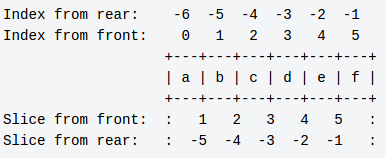

In [ ]:
a = ['a', 'b', 'c', 'd', 'e', 'f']

[begin: end: (direction)step]

In [ ]:
a[3::-1]

### Strings

[Docs](https://docs.python.org/3/library/stdtypes.html#text-sequence-type-str
)

Strings are the variable type that is used for storing text messages.

In [ ]:
s = 'as"d'
print(s)
s = "a'sd"
print(s)

In [ ]:
s = '''sdfsdfsdf
fsdfsdf
sdfsdfs
sdfsdfsdf
'''
print(s)

In [ ]:
s = "Hello world"
type(s)

In [ ]:
s = 'asd'
s.center(20, 't')

In [ ]:
# length of the string: the number of characters
len(s)

In [ ]:
help(len)

In [ ]:
# replace a substring in a string with something else
s = "Hello world Hello world"

s2 = s.replace("world", "test", 2)
print(s2)

We can index a character in a string using `[]`:

In [ ]:
s = "Hello world"

In [ ]:
s[0]

**Heads up MATLAB users:** Indexing start at 0!

We can extract a part of a string using the syntax `[start:stop]`, which extracts characters between index `start` and `stop` -1 (the character at index `stop` is not included):

In [ ]:
s[0:5]

In [ ]:
s[4:5]

If we omit either (or both) of `start` or `stop` from `[start:stop]`, the default is the beginning and the end of the string, respectively:

In [ ]:
s[:5]

In [ ]:
s[6:]

In [ ]:
s[:]

We can also define the step size using the syntax `[start:end:step]` (the default value for `step` is 1, as we saw above):

In [ ]:
s[::1]

In [ ]:
s[::2]

In [ ]:
s = 'abcdef'
s[4::-1]

This technique is called *slicing*. Read more about the syntax here: https://docs.python.org/3/library/functions.html#slice

Python has a very rich set of functions for text processing. See for example https://docs.python.org/3/library/string.html for more information.

### The half-open rule, stated once

`s[a:b]` gives you the characters from position `a` **up to but not including** `b`.

Two consequences worth memorising:

- `len(s[a:b])` is `b - a`. Always. That is *why* the rule exists.
- `s[:k]` and `s[k:]` fit together perfectly, with no gap and no overlap, for any `k`.

Python counts from 0 and excludes the end. Almost every other convention you have met in finance — quarters, months, "the first five days" — counts from 1 and includes the end. Converting between the two, in your head, at speed, is the single most common way to be off by one.

---
## 11 · f-strings

The 2025 notebook teaches `%` and `.format()`. Both still work and you will see them in older code. Neither is what you should write.

Put an `f` in front of the quote, and anything inside `{ }` is evaluated as Python and dropped into the string.

In [ ]:
ticker = "SBER"
close  = 299.9
ret    = 0.1015610651974288

print(f"{ticker} closed at {close}")
print(f"{ticker} returned {ret} over the year")

The second line is unreadable. A colon inside the braces says **how** to format the value:

In [ ]:
print(f"{ret:.2%}")        # as a percentage, 2 decimals
print(f"{ret:.4f}")        # as a decimal, 4 places
print(f"{close:10.2f}")    # right-aligned in a field 10 wide
print(f"{close:,.2f}")     # thousands separator
print(f"{ticker:>8} | {close:>8.2f} | {ret:>7.2%}")   # a table row

`{ret:.2%}` multiplies by 100 **and** adds the `%` sign. This is a real source of the percent-versus-decimal error: if you write `f"{ret*100:.2%}"` you get `1015.61%`, and the code runs perfectly.

Finally, `=` inside the braces prints the expression *and* its value — the fastest debugging tool in the language:

In [ ]:
n_days = 254
print(f"{n_days=}")
print(f"{n_days / 12 = :.1f}")

---
## 12 · Lists, tuples, dictionaries, sets

Four containers. The question to ask about each one: **can I change it after I make it, and what can I look things up by?**

### List

[Docs](https://docs.python.org/3/library/stdtypes.html#list)

Lists are very similar to strings, except that each element can be of any type.

The syntax for creating lists in Python is `[...]`:

In [ ]:
l = [1, 2, 3, 4]

print(type(l))
print(l)

We can use the same slicing techniques to manipulate lists as we could use on strings:


In [ ]:
print(l)

print(l[1:3])

print(l[::2])

**Heads up MATLAB users:** Indexing starts at 0!

In [ ]:
l[0]

Elements in a list do not all have to be of the same type:

In [ ]:
l = [1, 'a', 1.0, 1-1j]

print(l)

Python lists can be inhomogeneous and arbitrarily nested:

In [ ]:
nested_list = [1, [2, [3, [4, [5]]]]]
print(nested_list[1][1][1][1][0])


Lists play a very important role in Python. For example they are used in loops and other flow control structures (discussed below). There are a number of convenient functions for generating lists of various types, for example the `range` function:

In [ ]:
start = 10
stop = 30
step = 2

list(range(start, stop, step))

In [ ]:
# in python 3 range generates an iterator, which can be converted to a list using 'list(...)'.
# It has no effect in python 2
list(range(start, stop, step))

In [ ]:
list(range(-10, 10))

In [ ]:
s = 'abcdef'

In [ ]:
# convert a string to a list by type casting:
s2 = list(s)

s2

In [ ]:
s2 = [1, 5, 9, 2, 4, 7]
print(s2)

In [ ]:
w = sorted(s2)

In [ ]:
type(w)

In [ ]:
# sorting lists
s2.sort()

print(s2)

#### Adding, inserting, modifying, and removing elements from lists

We can modify lists by assigning new values to elements in the list. In technical jargon, lists are *mutable*.

In [ ]:
l[1:3] = ["d", "d"]

print(l)

Insert an element at an specific index using `insert`

In [ ]:
l.insert(0, "i")
l.insert(1, "n")
l.insert(2, "s")
l.insert(3, "e")
l.insert(4, "r")
l.insert(22, "t")

print(l)

Remove first element with specific value using 'remove'

In [ ]:
l.remove("t")

print(l)

Remove an element at a specific location using `del`:

In [ ]:
del l[7]
del l[6]

print(l)

See `help(list)` for more details, or read the online documentation

### Tuples

[Docs](https://docs.python.org/3/library/stdtypes.html#tuple)

Tuples are like lists, except that they cannot be modified once created, that is they are *immutable*.

In Python, tuples are created using the syntax `(..., ..., ...)`, or even `..., ...`:

In [ ]:
point = (10, 20)

print(point, type(point))

In [ ]:
point = 10, 20

print(point, type(point))

We can unpack a tuple by assigning it to a comma-separated list of variables:

In [ ]:
x, y = point

print("x =", x)
print("y =", y)

If we try to assign a new value to an element in a tuple we get an error:

> ⚠️ **This cell is supposed to raise an error.** That is the lesson. Run it, read the error type and the message, and move on — nothing is broken.

In [ ]:
point[0] = 20

### Dictionaries

[Docs](https://docs.python.org/3/library/stdtypes.html#mapping-types-dict)

Dictionaries are also like lists, except that each element is a key-value pair. The syntax for dictionaries is `{key1 : value1, ...}`:

In [ ]:
l = [1., 2., 3.]

In [ ]:
l[0]

In [ ]:
params = {"parameter1" : 1.0,
          "parameter2" : 2.0,
          "parameter3" : 3.0,}

print(type(params))
print(params)

In [ ]:
params[(1, 2, 3)] = 'ccc'

In [ ]:
params[[1, 2, 3, 4]] = 'qqwewe'

In [ ]:
print("parameter1 = " + str(params["parameter1"]))
print("parameter2 = " + str(params["parameter2"]))
print("parameter3 = " + str(params["parameter3"]))

In [ ]:
params["parameter1"] = "A"
params["parameter2"] = "B"

# add a new entry
params["parameter4"] = "D"

print("parameter1 = " + str(params["parameter1"]))
print("parameter2 = " + str(params["parameter2"]))
print("parameter3 = " + str(params["parameter3"]))
print("parameter4 = " + str(params["parameter4"]))

### Sets

[Docs](https://docs.python.org/3/library/stdtypes.html#set)

In [ ]:
x = ['apple', 'orange', 'apple', 'pear', 'orange', 'banana']

In [ ]:
len(x)

In [ ]:
x[2]

In [ ]:
basket = {'apple', 'orange', 'apple', 'pear', 'orange', 'banana'}
print(basket)                      # show that duplicates have been removed

In [ ]:
len(basket)

In [ ]:
'orange' in basket                 # fast membership testing
# 'crabgrass' in basket

In [ ]:
a = set('abracadabra')
b = set('alacazam')
a                                  # unique letters in a

In [ ]:
a - b                              # letters in a but not in b

In [ ]:
a | b                             # letters in a or b or both

In [ ]:
a & b                              # letters in both a and b

### Choosing a container

| | ordered? | mutable? | good for |
|---|---|---|---|
| `list` | yes | **yes** | a sequence you will add to or change — prices, dates, rows |
| `tuple` | yes | no | a fixed record that should not change — a coordinate, a returned pair |
| `dict` | yes (insertion) | **yes** | lookup by a key — ticker → price, month → average |
| `set` | no | **yes** | membership tests and removing duplicates |